### Experiment 6: Effect of Model Complexity
## Research Question

How does increasing the complexity of a Linear Regression model affect
training and validation performance on the California Housing dataset?

## Hypothesis

Increasing model complexity will initially improve predictive
performance by allowing the model to capture nonlinear relationships
and interactions in the data. However, excessive complexity is expected
to eventually increase the gap between training and validation
performance, indicating overfitting.

### Experimental Principle

Only model complexity should change.

Keep everything else fixed:

- Same dataset
- Same train/validation split
- Same features
- Same target
- Same preprocessing
- Same evaluation metrics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("E:\House Price Prediction ML Project\Data\Raw\housing.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\H'
<>:1: SyntaxWarning: invalid escape sequence '\H'
C:\Users\HP\AppData\Local\Temp\ipykernel_19444\4013469833.py:1: SyntaxWarning: invalid escape sequence '\H'
  df = pd.read_csv("E:\House Price Prediction ML Project\Data\Raw\housing.csv")


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
X = df.drop(columns=["median_house_value"])
y =df['median_house_value']

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


#Split the raw data inot train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

### 1. Select numerical features

In [10]:
features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income"
]

X_train_subset = X_train[features]
X_val_subset = X_test[features]

### 2. Impute missing values

In [11]:
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train_subset)
X_val_imputed = imputer.transform(X_val_subset)

### 3. Scale 

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)

### 4. Run the complexity experiment

In [14]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error

In [16]:
degrees = [1, 2, 3, 4]

results = []

for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly = poly.fit_transform(X_train_scaled)
    X_val_poly = poly.transform(X_val_scaled)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_predictions = model.predict(X_train_poly)
    val_predictions = model.predict(X_val_poly)

    y_train_RMSE = root_mean_squared_error(y_train, train_predictions)
    y_val_RMSE = root_mean_squared_error(y_test, val_predictions)

    y_train_MAE = mean_absolute_error(y_train, train_predictions)
    y_val_MAE = mean_absolute_error(y_test, val_predictions)

    y_train_R2 = r2_score(y_train, train_predictions)
    y_val_R2 = r2_score(y_test, val_predictions)

    results.append({
        "Degree": degree,
        "Number_of_Features": X_train_poly.shape[1],
        "Train_RMSE": y_train_RMSE,
        "Val_RMSE": y_val_RMSE,
        "Train_MAE": y_train_MAE,
        "Val_MAE": y_val_MAE,
        "Train_R2": y_train_R2,
        "Val_R2": y_val_R2
    })

results_df = pd.DataFrame(results)
results_df 


,Degree,Number_of_Features,Train_RMSE,Val_RMSE,Train_MAE,Val_MAE,Train_R2,Val_R2
0,1,8,69389.154322,7.085866e+04,50773.476720,51298.989683,0.635618,0.633822
1,2,44,63172.013767,8.006585e+04,44799.084802,45963.220657,0.697989,0.532479
2,3,164,58715.356358,2.176617e+05,41535.861439,46105.231678,0.739098,-2.455180
3,4,494,54024.370287,1.322668e+06,37985.124091,62608.036561,0.779122,-126.587539


### 5. Plot the bias-variance behavior

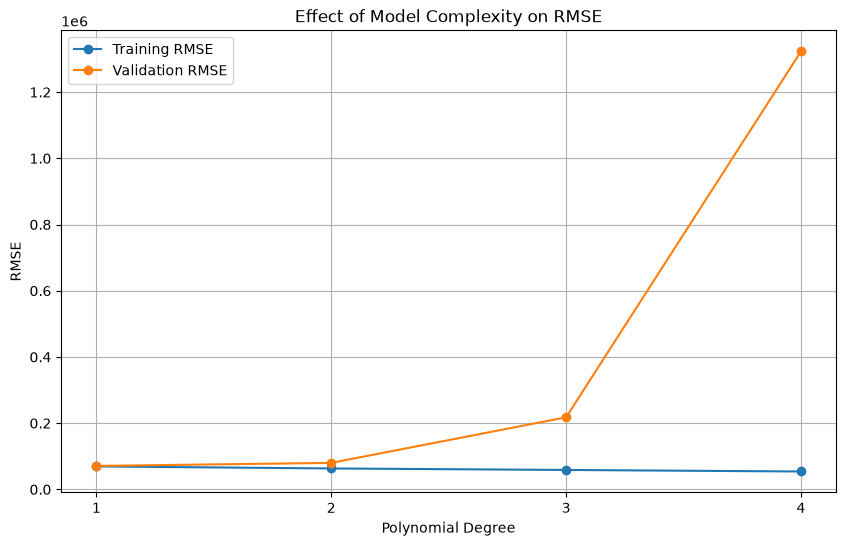

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    results_df["Degree"],
    results_df["Train_RMSE"],
    marker="o",
    label="Training RMSE"
)

plt.plot(
    results_df["Degree"],
    results_df["Val_RMSE"],
    marker="o",
    label="Validation RMSE"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Effect of Model Complexity on RMSE")
plt.xticks(degrees)
plt.legend()
plt.grid(True)

plt.show()

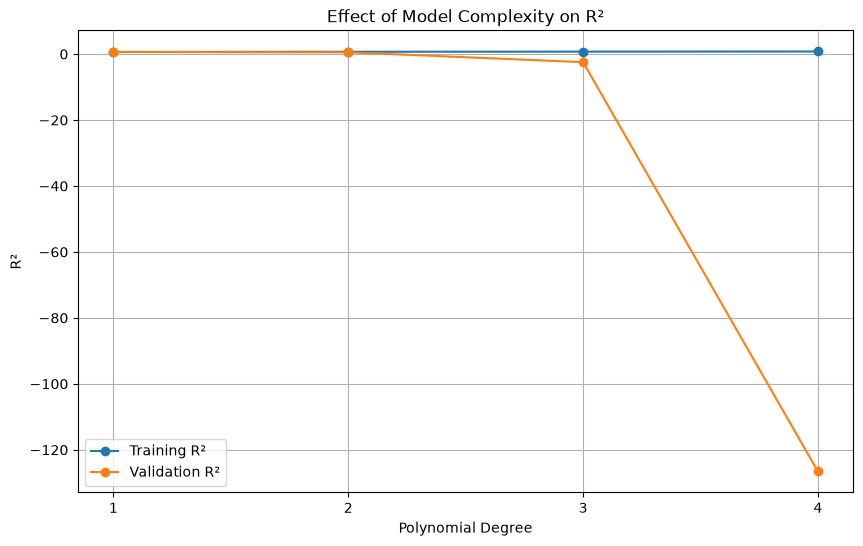

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    results_df["Degree"],
    results_df["Train_R2"],
    marker="o",
    label="Training R²"
)

plt.plot(
    results_df["Degree"],
    results_df["Val_R2"],
    marker="o",
    label="Validation R²"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R²")
plt.title("Effect of Model Complexity on R²")
plt.xticks(degrees)
plt.legend()
plt.grid(True)

plt.show()

In [20]:
results_df["RMSE_Gap"] = (
    results_df["Val_RMSE"]
    - results_df["Train_RMSE"]
)

results_df

,Degree,Number_of_Features,Train_RMSE,Val_RMSE,Train_MAE,Val_MAE,Train_R2,Val_R2,RMSE_Gap
0,1,8,69389.154322,7.085866e+04,50773.476720,51298.989683,0.635618,0.633822,1.469503e+03
1,2,44,63172.013767,8.006585e+04,44799.084802,45963.220657,0.697989,0.532479,1.689384e+04
2,3,164,58715.356358,2.176617e+05,41535.861439,46105.231678,0.739098,-2.455180,1.589463e+05
3,4,494,54024.370287,1.322668e+06,37985.124091,62608.036561,0.779122,-126.587539,1.268643e+06


## Conclusion

The results strongly support the hypothesis that increasing model
complexity can lead to overfitting.

As polynomial degree increased from 1 to 4, training performance
continuously improved. Training RMSE decreased from approximately
69,389 at degree 1 to 54,024 at degree 4, while training R² increased
from 0.636 to 0.779.

However, validation performance deteriorated as complexity increased.
Validation RMSE increased from approximately 70,859 at degree 1 to
80,066 at degree 2, 217,662 at degree 3, and 1,322,668 at degree 4.
Similarly, validation R² decreased from 0.634 at degree 1 to -126.588
at degree 4.

The growing gap between training and validation performance provides
strong evidence of overfitting. The model becomes increasingly capable
of fitting the training data but increasingly poor at generalizing to
unseen data.

In this experiment, the simplest linear model achieved the best
validation performance. Therefore, increasing model complexity without
controlling it does not necessarily improve predictive performance and
can substantially harm generalization.

## Hypothesis Result

**Hypothesis: Supported**

The hypothesis is strongly supported by the experimental results. Increasing
model complexity improved training performance, but progressively reduced
validation performance. Training RMSE decreased from 69,389 to 54,024, while
validation RMSE increased from 70,859 to 1,322,668 as polynomial degree
increased from 1 to 4.

The increasing gap between training and validation performance demonstrates
that higher model complexity led to overfitting and poorer generalization.
However, the expected initial improvement in validation performance was not
observed. The degree-1 model achieved the best validation performance among
the tested models.